In [1]:
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 20.6 MB/s eta 0:00:00


In [2]:
import os
import random
import shutil
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import os

if os.path.exists("/kaggle/input/dsai-unified-dataset"):
    DATA_PATH = "/kaggle/input/dsai-unified-dataset"
else:
    DATA_PATH = "/kaggle/input/datasets/ds22f1001123/dsai-unified-dataset"

print("Using dataset path:", DATA_PATH)

Using dataset path: /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset


In [4]:
train_images_path = os.path.join(DATA_PATH, 'images/train')
train_images = [os.path.join(train_images_path, f) 
              for f in os.listdir(train_images_path) 
              if f.endswith(('.jpg', '.png'))]
train_images.sort()

val_images_path = os.path.join(DATA_PATH, 'images/val')
all_val_images = [
    os.path.join(val_images_path, f)
    for f in os.listdir(val_images_path)
    if f.endswith(('.jpg', '.png'))
]
all_val_images.sort()

seed = 2306
random.seed(seed)
random.shuffle(all_val_images)

test_ratio = 0.5
n_test = int(len(all_val_images) * test_ratio)
test_images = all_val_images[:n_test]
val_images = all_val_images[n_test:]

print(f"Train: {len(train_images)}")
print(f"Val: {len(val_images)}")
print(f"Test: {len(test_images)}")

Train: 9358
Val: 1170
Test: 1170


In [5]:
def save_list(file_path, image_list):
    with open(file_path, "w") as f:
        for item in image_list:
            f.write(item + "\n")

save_list("train.txt", train_images)
save_list("val.txt", val_images)
save_list("test.txt", test_images)

In [6]:
with open("data.yaml", "w") as f:
    f.write(f"""
path: {DATA_PATH}

train: /kaggle/working/train.txt
val: /kaggle/working/val.txt
test: /kaggle/working/test.txt

names:
  0: person
  1: table
  2: potted plant
  3: chair
  4: sofa
  5: lamp
  6: door
  7: cabinet
  8: wardrobe
  9: refrigerator
  10: bed
""")

In [7]:
model = YOLO("yolo11s.pt")
DATA_YAML = "/kaggle/working/data.yaml"

# Model Training

In [8]:
results = model.train(
    data="/kaggle/working/data.yaml",

    # Training
    epochs=80,
    patience=10,
    imgsz=768,
    batch=32,
    device=0,

    # Augmentations
    fliplr=0.5,
    degrees=10,
    translate=0.15,
    scale=0.7,
    mosaic=1.0,
    mixup=0.2,

    hsv_h=0.015,
    hsv_s=0.6,
    hsv_v=0.4,

    # Scheduler / training behaviour
    cos_lr=True,
    close_mosaic=10,
    warmup_epochs=3,

    # Optimizer + tuned loss params
    optimizer="AdamW",
    lr0=0.001,
    weight_decay=0.0001,

    box=10.0,
    cls=0.5,
    dfl=2.0,

    # Reproducibility
    seed=2306,
    deterministic=True,

    # Output
    project="/kaggle/working/final_training",
    name="best_run_full_dataset",
    exist_ok=True
)

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=10.0, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10, deterministic=True, device=0, dfl=2.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.6, hsv_v=0.4, imgsz=768, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=best_run_full_dataset, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=10, per

# Model Evaluations

In [9]:
best_model_path = "/kaggle/working/final_training/best_run_full_dataset/weights/best.pt"
best_model = YOLO(best_model_path)

print("Best model path:", best_model_path)

Best model path: /kaggle/working/final_training/best_run_full_dataset/weights/best.pt


In [10]:
test_metrics = best_model.val(
    data="/kaggle/working/data.yaml",
    split="test",
    save_json=True,
    plots=True
)

print(f"mAP@50-95: {test_metrics.box.map:.4f}")
print(f"mAP@50:    {test_metrics.box.map50:.4f}")
print(f"Precision: {test_metrics.box.mp:.4f}")
print(f"Recall:    {test_metrics.box.mr:.4f}")

Ultralytics 8.4.33 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,417,057 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 6.0±3.7 ms, read: 11.6±5.3 MB/s, size: 113.8 KB)
val: Scanning /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset/labels/val... 1170 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1170/1170 105.2it/s 11.1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/ds22f1001123/dsai-unified-dataset/labels is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 74/74 3.7it/s 20.1s
                   all       1170       5179      0.693      0.598      0.658      0.441
                person        501       1825       0.81      0.634      0.739      0.489
                 table        326        490      0.758      0.614      0.708      0.481
          potted plant        206        581      0.737    

# Saving Final Metrics

In [11]:
import pandas as pd

final_results = pd.DataFrame([{
    "model": "YOLO11s",
    "epochs": 80,
    "imgsz": 768,
    "batch": 32,
    "optimizer": "AdamW",
    "lr0": 0.001,
    "weight_decay": 0.0001,
    "box": 10.0,
    "cls": 0.5,
    "dfl": 2.0,
    "mixup": 0.2,
    "scale": 0.7,
    "mAP50": test_metrics.box.map50,
    "mAP50_95": test_metrics.box.map,
    "precision": test_metrics.box.mp,
    "recall": test_metrics.box.mr
}])

final_results.to_csv("/kaggle/working/final_test_metrics.csv", index=False)
final_results

,model,epochs,imgsz,batch,optimizer,lr0,weight_decay,box,cls,dfl,mixup,scale,mAP50,mAP50_95,precision,recall
0,YOLO11s,80,768,32,AdamW,0.001,0.0001,10.0,0.5,2.0,0.2,0.7,0.657913,0.441459,0.693194,0.597689


# Evaluation Plots

In [12]:
import os

os.makedirs("/kaggle/working/report_plots", exist_ok=True)
print("Created /kaggle/working/report_plots")

Created /kaggle/working/report_plots


In [13]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

train_dir = "/kaggle/working/final_training/best_run_full_dataset"
val_dir = test_metrics.save_dir

print("Training dir:", train_dir)
print("Evaluation dir:", val_dir)

Training dir: /kaggle/working/final_training/best_run_full_dataset
Evaluation dir: /kaggle/working/runs/detect/val


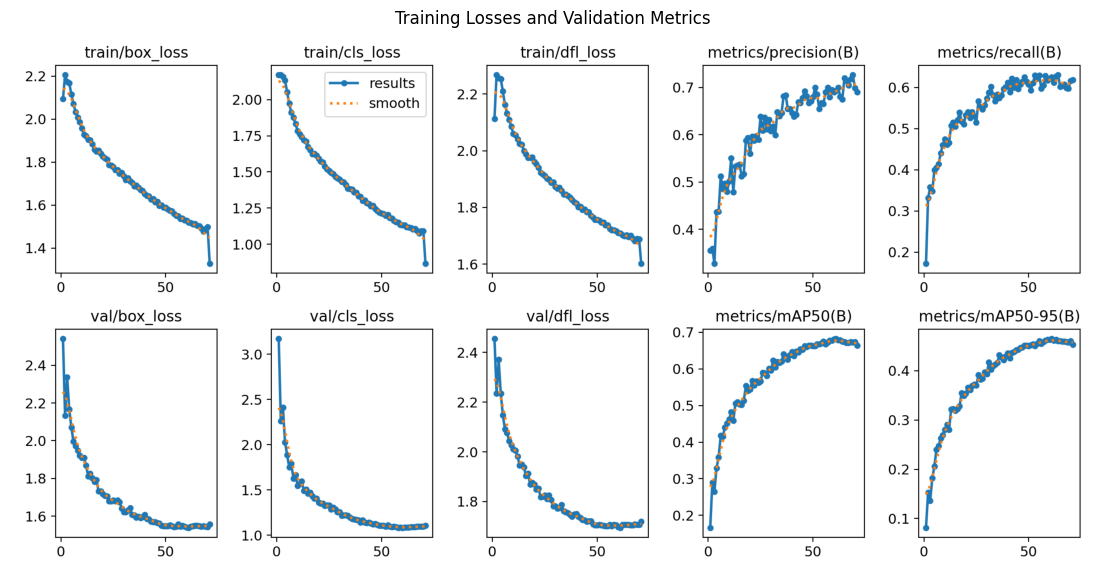

In [14]:
img = mpimg.imread(os.path.join(train_dir, "results.png"))
plt.figure(figsize=(14, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Training Losses and Validation Metrics")
plt.savefig("/kaggle/working/report_plots/result_metrics.png", dpi=300, bbox_inches="tight")
plt.show()

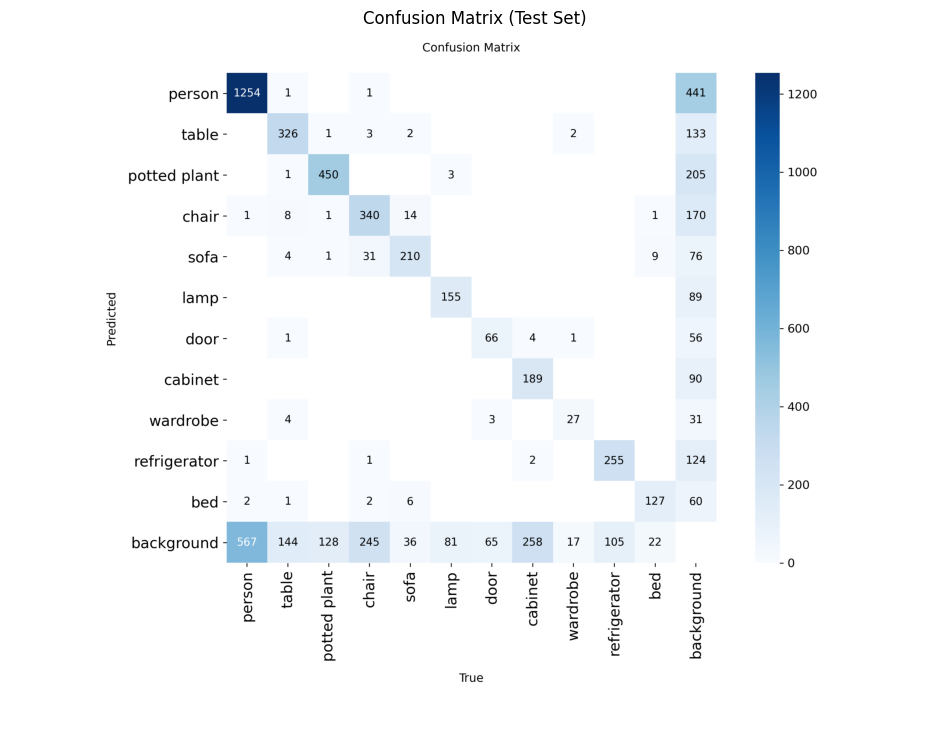

In [15]:
img = mpimg.imread(os.path.join(val_dir, "confusion_matrix.png"))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix (Test Set)")
plt.savefig("/kaggle/working/report_plots/conf_matrix_curve.png", dpi=300, bbox_inches="tight")
plt.show()

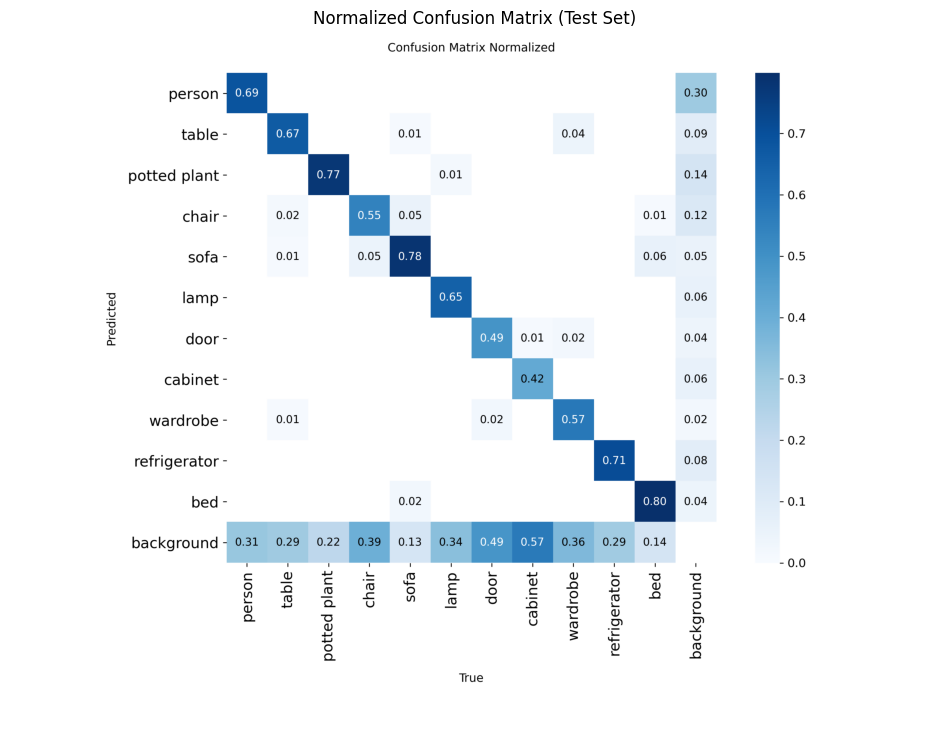

In [16]:
img = mpimg.imread(os.path.join(val_dir, "confusion_matrix_normalized.png"))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Normalized Confusion Matrix (Test Set)")
plt.savefig("/kaggle/working/report_plots/norm_conf_matrix_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [17]:
img = mpimg.imread(os.path.join(val_dir, "PR_curve.png"))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Precision-Recall Curve")
plt.savefig("/kaggle/working/report_plots/precision-recall_confidence_curve.png", dpi=300, bbox_inches="tight")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/runs/detect/val/PR_curve.png'

In [ ]:
img = mpimg.imread(os.path.join(val_dir, "F1_curve.png"))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Confidence Curve")
plt.savefig("/kaggle/working/report_plots/f1_confidence_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
img = mpimg.imread(os.path.join(val_dir, "P_curve.png"))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Precision Confidence Curve")
plt.savefig("/kaggle/working/report_plots/precision_confidence_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
img = mpimg.imread(os.path.join(val_dir, "R_curve.png"))
plt.figure(figsize=(12, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Recall Confidence Curve")
plt.savefig("/kaggle/working/report_plots/recall_confidence_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Qualitative Results

In [ ]:
with open("/kaggle/working/test.txt", "r") as f:
    test_images = [line.strip() for line in f.readlines()]

print("Number of test images:", len(test_images))
print("Sample:", test_images[:5])

In [ ]:
pred_results = best_model.predict(
    source="/kaggle/working/test.txt",
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project="/kaggle/working/final_predictions",
    name="test_preds",
    exist_ok=True
)

In [ ]:
import random
from PIL import Image

pred_img_dir = "/kaggle/working/final_predictions/test_preds"

pred_images = [
    os.path.join(pred_img_dir, f)
    for f in os.listdir(pred_img_dir)
    if f.endswith((".jpg", ".png", ".jpeg"))
]

sample_preds = random.sample(pred_images, min(6, len(pred_images)))

plt.figure(figsize=(18, 12))
for i, img_path in enumerate(sample_preds):
    img = Image.open(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(os.path.basename(img_path))
plt.tight_layout()
plt.show()

# Error Analysis

In [ ]:
from collections import Counter

# class names
class_names = {
    0: "person",
    1: "table",
    2: "potted plant",
    3: "chair",
    4: "sofa",
    5: "lamp",
    6: "door",
    7: "cabinet",
    8: "wardrobe",
    9: "refrigerator",
    10: "bed"
}

# paths
pred_label_dir = "/kaggle/working/final_predictions/test_preds/labels"

gt_counts = Counter()
pred_counts = Counter()

# Count GT labels from test images
for img_path in test_images:
    label_path = img_path.replace("/images/", "/labels/")
    label_path = os.path.splitext(label_path)[0] + ".txt"

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            for line in f:
                cls = int(line.strip().split()[0])
                gt_counts[cls] += 1

# Count predicted labels
if os.path.exists(pred_label_dir):
    for lbl_file in os.listdir(pred_label_dir):
        lbl_path = os.path.join(pred_label_dir, lbl_file)
        with open(lbl_path, "r") as f:
            for line in f:
                cls = int(line.strip().split()[0])
                pred_counts[cls] += 1

comparison_df = pd.DataFrame({
    "class_id": list(class_names.keys()),
    "class_name": [class_names[i] for i in class_names.keys()],
    "ground_truth_count": [gt_counts[i] for i in class_names.keys()],
    "predicted_count": [pred_counts[i] for i in class_names.keys()],
})

comparison_df["difference"] = comparison_df["predicted_count"] - comparison_df["ground_truth_count"]

comparison_df.to_csv("/kaggle/working/classwise_prediction_comparison.csv", index=False)
comparison_df

In [ ]:
comparison_df.plot(
    x="class_name",
    y=["ground_truth_count", "predicted_count"],
    kind="bar",
    figsize=(14, 6)
)
plt.title("Ground Truth vs Predicted Object Counts per Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Saving all Outputs

In [ ]:
important_outputs = {
    "best_model": best_model_path,
    "training_results_dir": train_dir,
    "test_eval_dir": str(val_dir),
    "predictions_dir": "/kaggle/working/final_predictions/test_preds",
    "final_metrics_csv": "/kaggle/working/final_test_metrics.csv",
    "classwise_comparison_csv": "/kaggle/working/classwise_prediction_comparison.csv"
}

for k, v in important_outputs.items():
    print(f"{k}: {v}")